In [2]:
import torch
import torch.nn as nn
import numpy as np



In [3]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
# 0 = all messages are logged (default behavior)
# 1 = INFO messages are not printed
# 2 = INFO and WARNING messages are not printed
# 3 = INFO, WARNING, and ERROR messages are not printed

import datetime

import IPython
import IPython.display
import matplotlib as mpl
import matplotlib.pyplot as plt


from sklearn.preprocessing import StandardScaler, MinMaxScaler
from keras.models import load_model
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
#from google.colab import drive
#drive.mount('/content/gdrive')

mpl.rcParams['figure.figsize'] = (8, 6)
mpl.rcParams['axes.grid'] = False

#import warnings
# https://stackoverflow.com/questions/15777951/how-to-suppress-pandas-future-warning
#warnings.simplefilter(action='ignore', category=FutureWarning)
#warnings.simplefilter(action='ignore', category=Warning)

tf.get_logger().setLevel('ERROR')
tf.autograph.set_verbosity(0)

import logging
tf.get_logger().setLevel(logging.ERROR)

# https://stackoverflow.com/questions/65697623/tensorflow-warning-found-untraced-functions-such-as-lstm-cell-6-layer-call-and
import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)

In [4]:
dfs = {}

df = pd.read_csv('/content/Station1_Revised_Final_Data.csv', sep=",", parse_dates=["Unnamed: 0"], index_col="Unnamed: 0")
dfs['Station1'] = df
# for index in range(0, 6):
#   df = pd.read_csv('Station' + str(index + 1) + '_simulated_cleaned_merged_data.csv', sep=",", parse_dates=["Unnamed: 0"], index_col="Unnamed: 0")
#   dfs['Station' + str(index + 1)] = df
#   df.index = pd.to_datetime(df.index)

print(df.isna().sum())


Ppt              0
SWC_5            0
SWC_10           0
SWC_20           0
SWC_50           0
T_5              0
T_10             0
T_20             0
T_50             0
Tair             0
RH               0
Windspeed        0
Winddirection    0
Srad             0
Latitude         0
Longitude        0
dtype: int64


In [5]:
df = df.iloc[:24 * 365]
print(df.describe().transpose())


df.shape


                count        mean           std      min        25%       50%  \
Ppt            8760.0    0.055753  7.851592e-01   0.0000    0.00000    0.0000   
SWC_5          8760.0    0.120606  5.006897e-02   0.0430    0.06700    0.1290   
SWC_10         8760.0    0.165131  4.397464e-02   0.0940    0.12000    0.1770   
SWC_20         8760.0    0.143380  3.815596e-02   0.0870    0.10300    0.1530   
SWC_50         8760.0    0.146307  4.058124e-02   0.0870    0.09800    0.1540   
T_5            8760.0   22.601484  1.035924e+01   0.7600   14.65000   22.9650   
T_10           8760.0   22.669767  9.691173e+00   2.7600   14.92000   23.0100   
T_20           8760.0   22.655927  9.204242e+00   4.2600   15.13500   22.8800   
T_50           8760.0   22.559511  7.806723e+00   7.8800   15.65000   22.4400   
Tair           8760.0   18.831689  8.954406e+00  -7.5600   13.18000   20.5900   
RH             8760.0   68.085942  2.237972e+01   6.8000   49.76000   70.9300   
Windspeed      8760.0    1.8

(8760, 16)

In [6]:
import numpy as np
import pandas as pd

def engineer_data(dfs, boolean):
    # Constants for day and year calculations
    day = 24 * 60 * 60
    year = 365.2425 * day

    for station, df in dfs.items():
        # Drop rows with NaN values to ensure clean data
        df = df.dropna()

        # Extract windspeed and wind direction
        wv = df['Windspeed']
        wd_rad = np.deg2rad(df['Winddirection'])  # Convert degrees to radians

        # Ensure the index is in datetime format
        df.index = pd.to_datetime(df.index)

        # Convert timestamp index to seconds
        timestamp_s = df.index.map(pd.Timestamp.timestamp)

        # Extract latitude and longitude
        lat = np.deg2rad(df['Latitude'])  # Convert latitude to radians
        lon = np.deg2rad(df['Longitude'])  # Convert longitude to radians

        # Engineer wind components

        # print("HELLO", wv * np.cos(wd_rad))
        # print("AHHHHH",wd_rad)

        if boolean:
          df['Wx'] = wv * np.cos(wd_rad)
          df['Wy'] = wv * np.sin(wd_rad)

        # Engineer time-based cyclic features
        df['Day sin'] = np.sin(timestamp_s * (2 * np.pi / day))
        df['Day cos'] = np.cos(timestamp_s * (2 * np.pi / day))
        df['Year sin'] = np.sin(timestamp_s * (2 * np.pi / year))
        df['Year cos'] = np.cos(timestamp_s * (2 * np.pi / year))

        # Engineer Cartesian coordinates for latitude and longitude
        df['x_cord'] = np.cos(lat) * np.cos(lon)
        df['y_cord'] = np.cos(lat) * np.sin(lon)
        df['z_cord'] = np.sin(lat)

        # Update the DataFrame in the dictionary
        dfs[station] = df

    return dfs





In [7]:
engineer_data(dfs, False)

engineer_data(dfs, True)



{'Station1':                      Ppt  SWC_5  SWC_10  SWC_20  SWC_50   T_5  T_10  T_20  \
 2015-01-01 00:00:00  0.0  0.139   0.178   0.148   0.152  2.81  4.40  5.77   
 2015-01-01 01:00:00  0.0  0.139   0.178   0.148   0.152  2.86  4.38  5.71   
 2015-01-01 02:00:00  0.0  0.139   0.178   0.148   0.152  2.89  4.35  5.66   
 2015-01-01 03:00:00  0.0  0.139   0.178   0.148   0.152  2.90  4.33  5.62   
 2015-01-01 04:00:00  0.0  0.139   0.178   0.148   0.152  2.96  4.32  5.59   
 ...                  ...    ...     ...     ...     ...   ...   ...   ...   
 2020-12-31 19:00:00  0.0  0.242   0.193   0.182   0.099  5.46  6.95  8.62   
 2020-12-31 20:00:00  0.0  0.236   0.191   0.182   0.099  5.43  6.80  8.40   
 2020-12-31 21:00:00  0.0  0.232   0.190   0.181   0.099  5.30  6.68  8.24   
 2020-12-31 22:00:00  0.0  0.229   0.189   0.181   0.099  5.29  6.55  8.09   
 2020-12-31 23:00:00  0.0  0.227   0.188   0.181   0.099  5.28  6.50  7.96   
 
                       T_50   Tair  ...  Longitude

In [8]:
dfs['Station1'].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Ppt,52560.0,6.820478e-02,8.405104e-01,-1.464373,0.000000,0.000000e+00,0.000000,40.640000
SWC_5,52560.0,1.402540e-01,5.154907e-02,0.004612,0.095000,1.340000e-01,0.183000,0.309000
SWC_10,52560.0,1.571126e-01,4.093361e-02,-0.023168,0.123000,1.540000e-01,0.192000,0.298000
SWC_20,52560.0,1.372937e-01,3.346671e-02,0.049357,0.105000,1.360000e-01,0.165000,0.235000
SWC_50,52560.0,1.373766e-01,3.578278e-02,0.076554,0.103000,1.290000e-01,0.170000,0.249000
T_5,52560.0,2.299284e+01,9.495459e+00,0.760000,15.550000,2.293000e+01,30.080000,49.960000
T_10,52560.0,2.300737e+01,8.874525e+00,2.000000,15.800000,2.311000e+01,30.170000,44.440000
T_20,52560.0,2.294840e+01,8.384273e+00,3.270000,15.940000,2.308000e+01,30.010000,41.200000
T_50,52560.0,2.280507e+01,7.007613e+00,7.880000,16.520000,2.259000e+01,29.230000,35.400000
Tair,52560.0,1.414288e+01,2.328434e+01,-173.200000,11.577500,1.933000e+01,24.420000,172.476413


In [9]:

def scale_data(dfs):
    for station, df in dfs.items():
        cur_df = df.copy()
        d_sin = cur_df.pop("Day sin")
        d_cos = cur_df.pop("Day cos")
        y_sin = cur_df.pop("Year sin")
        y_cos = cur_df.pop("Year cos")
        x = cur_df.pop("x_cord")
        y = cur_df.pop("y_cord")
        z = cur_df.pop("z_cord")
        scaler = MinMaxScaler()
        scaled_df = pd.DataFrame(data=scaler.fit_transform(cur_df), columns=cur_df.columns, index=cur_df.index)
        scaled_df["Day sin"] = d_sin.values
        scaled_df["Day cos"] = d_cos.values
        scaled_df["Year sin"] = y_sin.values
        scaled_df["Year cos"] = y_cos.values
        scaled_df["x_cord"] = x.values
        scaled_df["y_cord"] = y.values
        scaled_df["z_cord"] = z.values
        dfs[station] = scaled_df

In [10]:
scale_data(dfs)

In [11]:
#Definitions
TARGET_COL = "SWC_5"
TRAIN_SPLIT = 0.7
VAL_SPLIT = 0.2
WINDOW_SIZE = 24 * 7
SHIFT_AMT = 10
PAT = 20
MAX_EPOCHS = 25

df = dfs['Station1']

In [12]:
def split(df, target_col=TARGET_COL, train_split = TRAIN_SPLIT, val_split = VAL_SPLIT):
  print(df.columns)
  target_idx = df.columns.get_loc(target_col)
  train_set = df[ : int(len(df) * train_split)].values
  val_set = df[int(len(df) * train_split) : int(len(df) * (train_split + val_split))].values
  test_set = df[int(len(df) * (train_split + val_split)) :].values
  return (train_set, val_set, test_set, target_idx)

In [13]:
import numpy as np

def generate_windows(data, window_size=24, shift=24, target_idx=0, output_size=1):
    labels = data[:, target_idx]

    X = []
    y = []
    for i in range(len(data) - window_size - shift - output_size + 1):
        # Get window based on input width
        window = data[i : i + window_size]
        # Get target sequence of `output_size` future steps
        window_label = labels[i + window_size + shift : i + window_size + shift + output_size]

        X.append(window)
        y.append(window_label)

    # Return data windows and corresponding label sequences
    return np.array(X), np.array(y)


# given data and its labels, divide the data into batches of size batch_size
def generate_batches(X, y, batch_size=32):
    # divides data into batches, drops any remainder batches smaller than specified batch size.
    # allows models to run with any batch size
    tf_dataset = tf.data.Dataset.from_tensor_slices((X, y))
    tf_dataset = tf_dataset.repeat().batch(batch_size=batch_size, drop_remainder=True)

    # tf_dataset repeats indefinitely, need to compute number of step updates to complete 1 epoch
    steps_per_epoch = len(X) // batch_size

    return (tf_dataset, steps_per_epoch)


In [14]:
output_size = 2
def preprocess_data(df):
    # data cleaning and feature engineering
    train_set, val_set, test_set, target_idx = split(df)


    # create window data for each dataset
    X_train, y_train = generate_windows(train_set, window_size=WINDOW_SIZE, shift=SHIFT_AMT, target_idx=target_idx,output_size=output_size)
    X_val, y_val = generate_windows(val_set, window_size=WINDOW_SIZE, shift=SHIFT_AMT, target_idx=target_idx, output_size=output_size)
    X_test, y_test = generate_windows(test_set, window_size=WINDOW_SIZE, shift=SHIFT_AMT, target_idx=target_idx, output_size=output_size)

    # generate batches for each dataset
    train_dataset, steps_per_epoch = generate_batches(X_train, y_train)

    return (X_train, y_train, X_val, y_val, X_test, y_test)

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np


In [16]:
BATCH_SIZE = 128
X_train, y_train, X_val, y_val, X_test, y_test = preprocess_data(df)





Index(['Ppt', 'SWC_5', 'SWC_10', 'SWC_20', 'SWC_50', 'T_5', 'T_10', 'T_20',
       'T_50', 'Tair', 'RH', 'Windspeed', 'Winddirection', 'Srad', 'Latitude',
       'Longitude', 'Wx', 'Wy', 'Day sin', 'Day cos', 'Year sin', 'Year cos',
       'x_cord', 'y_cord', 'z_cord'],
      dtype='object')


In [17]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)




(36613, 168, 25)
(10332, 168, 25)
(5078, 168, 25)


In [18]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)  # Shape: (num_samples, seq_len, input_dim)
        self.y = torch.tensor(y, dtype=torch.float32)  # Shape: (num_samples)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 128

train_dataset = TimeSeriesDataset(X_train, y_train)
val_dataset = TimeSeriesDataset(X_val, y_val)
test_dataset = TimeSeriesDataset(X_test, y_test)

#mini batching
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


In [19]:
import torch
import torch.nn as nn

class TransformerModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, n_heads, dim_feedforward=128, dropout=0.0, output_size=1):
        super(TransformerModel, self).__init__()

        self.input_proj = nn.Linear(input_dim, hidden_dim)

        self.transformer_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=n_heads,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )

        # https://github.com/dlsyscourse/public_notebooks/blob/main/transformer_implementation.ipynb
        self.transformer_layer.linear1.bias.data.zero_()
        self.transformer_layer.linear2.bias.data.zero_()

        # change the output layer to match the target shape

        self.output_layer = nn.Linear(hidden_dim, output_size)

    def forward(self, x):

        x = self.input_proj(x)  # shape: (batch_size, seq_len, hidden_dim)

        # Create a causal mask shown in the tutorial :
        # https://github.com/dlsyscourse/public_notebooks/blob/main/transformer_implementation.ipynb
        seq_len = x.size(1)
        M = torch.triu(torch.full((seq_len, seq_len), float('-inf')), diagonal=1).to(x.device)

        # transformer
        transformer_output = self.transformer_layer(x, src_mask=M)  # Shape: (batch_size, seq_len, hidden_dim)

        # mean pooling
        transformer_output = transformer_output.mean(dim=1)  # Shape: (batch_size, hidden_dim)

        #only get the output layer
        output = self.output_layer(transformer_output)  # Shape: (batch_size, 2)

        return output  # Return the output without squeezing

In [20]:
input_dim = X_train.shape[2]
hidden_dim = 64                #need to check this
n_heads = 4                    # need to check this
dim_feedforward = 128          # need to check this
dropout = 0.1                  # need to check this

model = TransformerModel(input_dim, hidden_dim, n_heads, dim_feedforward, dropout,output_size=output_size)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# loss is mse
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [21]:
import torch.nn.functional as F
import matplotlib.pyplot as plt

# looking at losses
train_losses_per_epoch = []
val_losses_per_epoch = []

num_epochs = 25

for epoch in range(num_epochs):
    model.train()
    train_losses = []
    mse_losses = []
    mae_losses = []
    mape_losses = []

    # Training Phase
    for X_batch, y_batch in train_loader:
        # Move data to device
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)


        optimizer.zero_grad()

        #forward prop
        outputs = model(X_batch)  # Shape: (batch_size)

        # get loss
        loss = criterion(outputs, y_batch)

        # backprop
        loss.backward()

        # update weights
        optimizer.step()

        # record loss
        train_losses.append(loss.item())

        #get other metrics
        mse = F.mse_loss(outputs, y_batch).item()
        mae = F.l1_loss(outputs, y_batch).item()

        mape = (torch.abs((y_batch - outputs) / (y_batch)).mean() * 100).item()

        # Record each metric
        mse_losses.append(mse)
        mae_losses.append(mae)
        mape_losses.append(mape)

    #  average metrics for this epoch
    avg_train_loss = sum(train_losses) / len(train_losses)
    avg_mse = sum(mse_losses) / len(mse_losses)
    avg_mae = sum(mae_losses) / len(mae_losses)
    avg_mape = sum(mape_losses) / len(mape_losses)

    #  average training loss for plotting
    train_losses_per_epoch.append(avg_train_loss)

    # validation
    model.eval()
    val_losses = []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)

            val_loss = criterion(outputs, y_batch)
            val_losses.append(val_loss.item())

    avg_val_loss = sum(val_losses) / len(val_losses)
    val_losses_per_epoch.append(avg_val_loss)

    # Print epoch results
    print(f'Epoch [{epoch+1}/{num_epochs}], '
          f'Train Loss: {avg_train_loss:.6f}, '
          f'Val Loss: {avg_val_loss:.6f}, '
          f'MSE: {avg_mse:.6f}, '
          f'MAE: {avg_mae:.6f}, '
          f'MAPE: {avg_mape:.2f}%')



Epoch [1/25], Train Loss: 0.023383, Val Loss: 0.011821, MSE: 0.023383, MAE: 0.103680, MAPE: inf%
Epoch [2/25], Train Loss: 0.008717, Val Loss: 0.009499, MSE: 0.008717, MAE: 0.064805, MAPE: inf%
Epoch [3/25], Train Loss: 0.007521, Val Loss: 0.009592, MSE: 0.007521, MAE: 0.059309, MAPE: inf%
Epoch [4/25], Train Loss: 0.006635, Val Loss: 0.009014, MSE: 0.006635, MAE: 0.055171, MAPE: inf%
Epoch [5/25], Train Loss: 0.006216, Val Loss: 0.012582, MSE: 0.006216, MAE: 0.053026, MAPE: inf%
Epoch [6/25], Train Loss: 0.005837, Val Loss: 0.008942, MSE: 0.005837, MAE: 0.051357, MAPE: inf%
Epoch [7/25], Train Loss: 0.005249, Val Loss: 0.008682, MSE: 0.005249, MAE: 0.048103, MAPE: inf%
Epoch [8/25], Train Loss: 0.005093, Val Loss: 0.010095, MSE: 0.005093, MAE: 0.047792, MAPE: inf%
Epoch [9/25], Train Loss: 0.004929, Val Loss: 0.009621, MSE: 0.004929, MAE: 0.046942, MAPE: inf%
Epoch [10/25], Train Loss: 0.004667, Val Loss: 0.010587, MSE: 0.004667, MAE: 0.045390, MAPE: inf%
Epoch [11/25], Train Loss: 0.

In [22]:
import torch.nn.functional as F  # For MSE and MAE functions

model.eval()

test_losses = []
mse_losses = []
mae_losses = []
mape_losses = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        # move data to the appropriate device
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # forward pass to get model predictions
        outputs = model(X_batch)

        #primary losses with mse as loss fuction
        loss = criterion(outputs, y_batch)
        test_losses.append(loss.item())

        # additional metrics
        mse = F.mse_loss(outputs, y_batch).item()
        mae = F.l1_loss(outputs, y_batch).item()

        mape = (torch.abs((y_batch - outputs) / y_batch).mean() * 100).item()

        mse_losses.append(mse)
        mae_losses.append(mae)
        mape_losses.append(mape)

avg_test_loss = sum(test_losses) / len(test_losses)
avg_mse = sum(mse_losses) / len(mse_losses)
avg_mae = sum(mae_losses) / len(mae_losses)
avg_mape = sum(mape_losses) / len(mape_losses)

print(f'Test Loss (MSE): {avg_test_loss:.6f}')
print(f'Average MSE: {avg_mse:.6f}')
print(f'Average MAE: {avg_mae:.6f}')
print(f'Average MAPE: {avg_mape:.2f}%')


Test Loss (MSE): 0.009984
Average MSE: 0.009984
Average MAE: 0.073468
Average MAPE: 18.94%


In [23]:
# Put the model in evaluation mode
model.eval()

all_predictions = []
all_actuals = []

# No gradient computation needed for evaluation
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        # Move data to the appropriate device
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        # Get the model's predictions
        predictions = model(X_batch)  # Shape: (batch_size)

        # Move predictions and actuals back to CPU and convert to numpy
        all_predictions.extend(predictions.cpu().numpy())
        all_actuals.extend(y_batch.cpu().numpy())

# Convert lists to numpy arrays for easy plotting
all_predictions = np.array(all_predictions)
all_actuals = np.array(all_actuals)


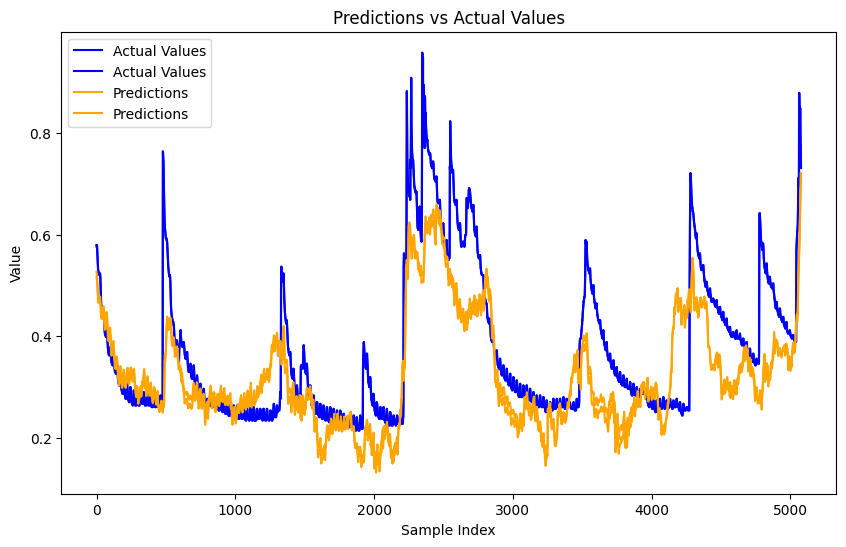

In [24]:
import matplotlib.pyplot as plt

# Plot predictions vs actual values in the test et
plt.figure(figsize=(10, 6))

# Plot actual values
plt.plot(all_actuals, label='Actual Values', color='blue', linestyle='-')
# Plot predictions
plt.plot(all_predictions, label='Predictions', color='orange', linestyle='-')

# Adding labels and title
plt.xlabel('Sample Index')
plt.ylabel('Value')
plt.title('Predictions vs Actual Values')
plt.legend()

# Show plot
plt.show()


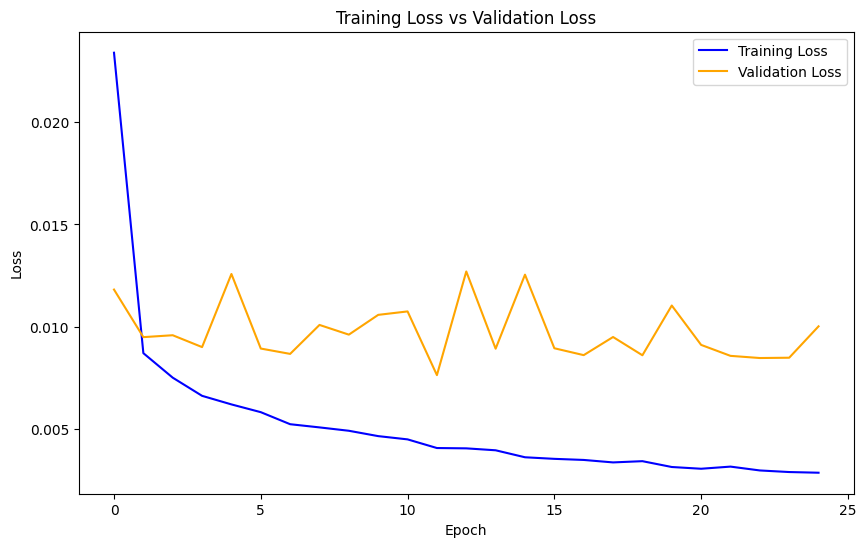

In [25]:
# Plotting Training Loss vs. Validation Loss
plt.figure(figsize=(10, 6))
plt.plot(train_losses_per_epoch, label='Training Loss', color='blue')
plt.plot(val_losses_per_epoch, label='Validation Loss', color='orange')

# Adding labels and title
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss vs Validation Loss')
plt.legend()

# Show plot
plt.show()
